# **Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import itertools
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam,RMSprop

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# **1.  Data Understanding and Preprocessing**

## **1.Exploratory Data Analysis**

In [2]:
df = pd.read_csv("energy_data_set.csv")

In [3]:
df.shape

(19735, 29)

* **Dataset contains 19735 records and 28 Features**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

* **All variables are numeric data type.**

### setting index as date

In [5]:
df.index = df['date'].tolist()
df.drop(columns = "date", inplace =True)

### **1. Correlation plot**

<Axes: >

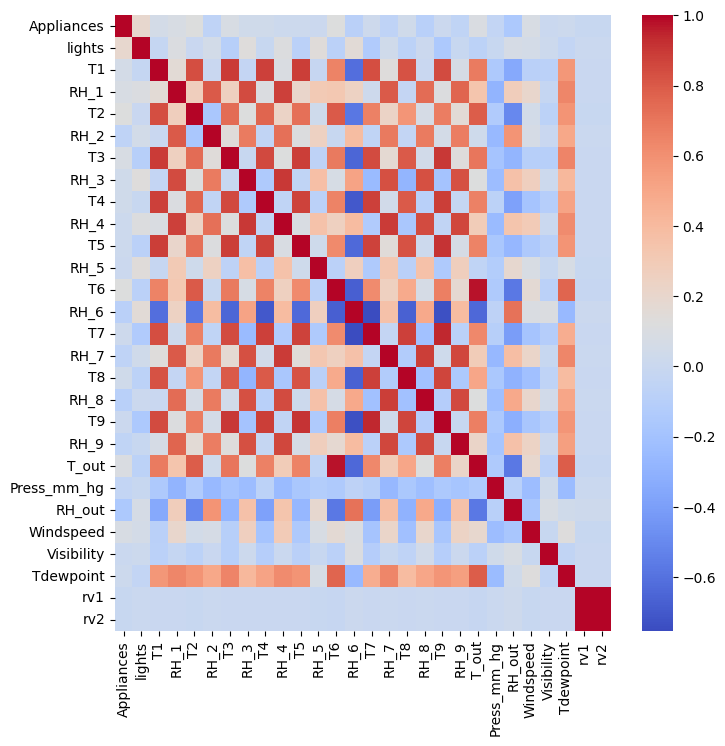

In [6]:
cor_data = df.corr()
plt.figure(figsize = [8,8])
sns.heatmap(cor_data, annot = False,cmap='coolwarm')

* **According to this correlation plot,**
  * **Appliances feature has low correlation values with other features.**
  * **We can see that there is a Multicollinearity in dataset.**

In [7]:
cor_data = pd.DataFrame(cor_data)['Appliances']
abs(cor_data).sort_values(ascending = False)

,Appliances
Appliances,1.000000
lights,0.197278
RH_out,0.152282
T2,0.120073
T6,0.117638
T_out,0.099155
RH_8,0.094039
Windspeed,0.087122
RH_1,0.086031
T3,0.085060


* **According to this dataframe, we can confirm that all variables have low correlation with Target variable.**

### **2. Seasonality of target variable**

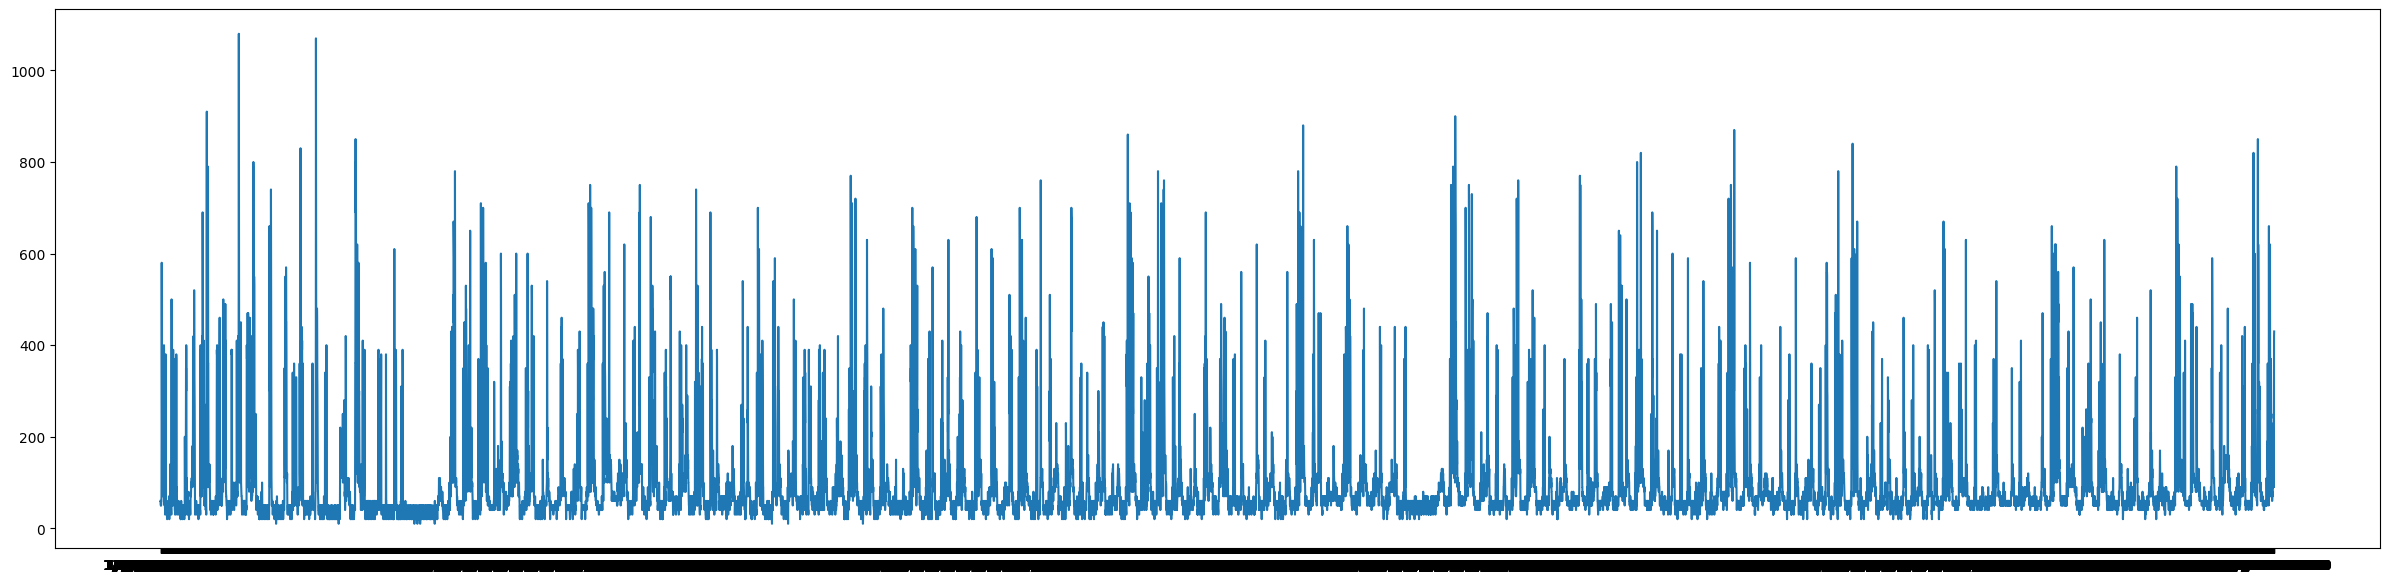

In [ ]:
plt.figure(figsize =[30,7])
plt.plot(df['Appliances'])
plt.show()

* **Using this plot, we can't get any information about variable 'Appliances'**

#### Setting date and time as index

In [8]:
df.index = pd.to_datetime(df.index)

* **Now, check whether what are the relationships between Appliances and hour/day/month**

#### Trend with pivot table

In [9]:
df['hour'] = df.index.hour
df['day'] = df.index.date
df['month'] = df.index.month

In [10]:
pivot1 = df.pivot_table(index = 'hour',values = 'Appliances')
pivot12 = df.pivot_table(index = 'hour',values = 'Appliances',columns = 'day')


#### **Energy consumption throughtout a day**

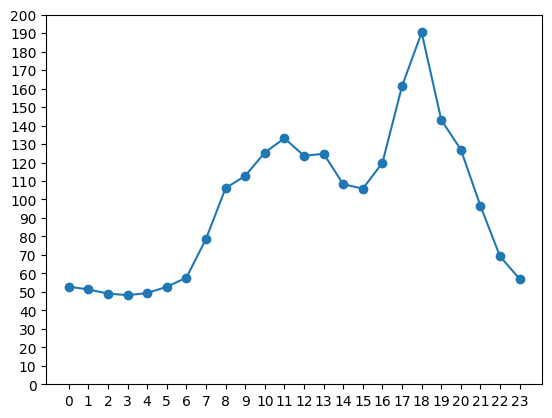

In [ ]:
plt.plot(pivot1, marker = "o")
plt.xticks(range(0,24,1))
plt.yticks(range(0,210,10))
plt.show()

* **same as day life energy consumption**
  * **peak of energy comsumption is around 6.00 pm**
  * **low energy comsumption is from midnight to early morning**

#### **Energy consumption daywise plot**

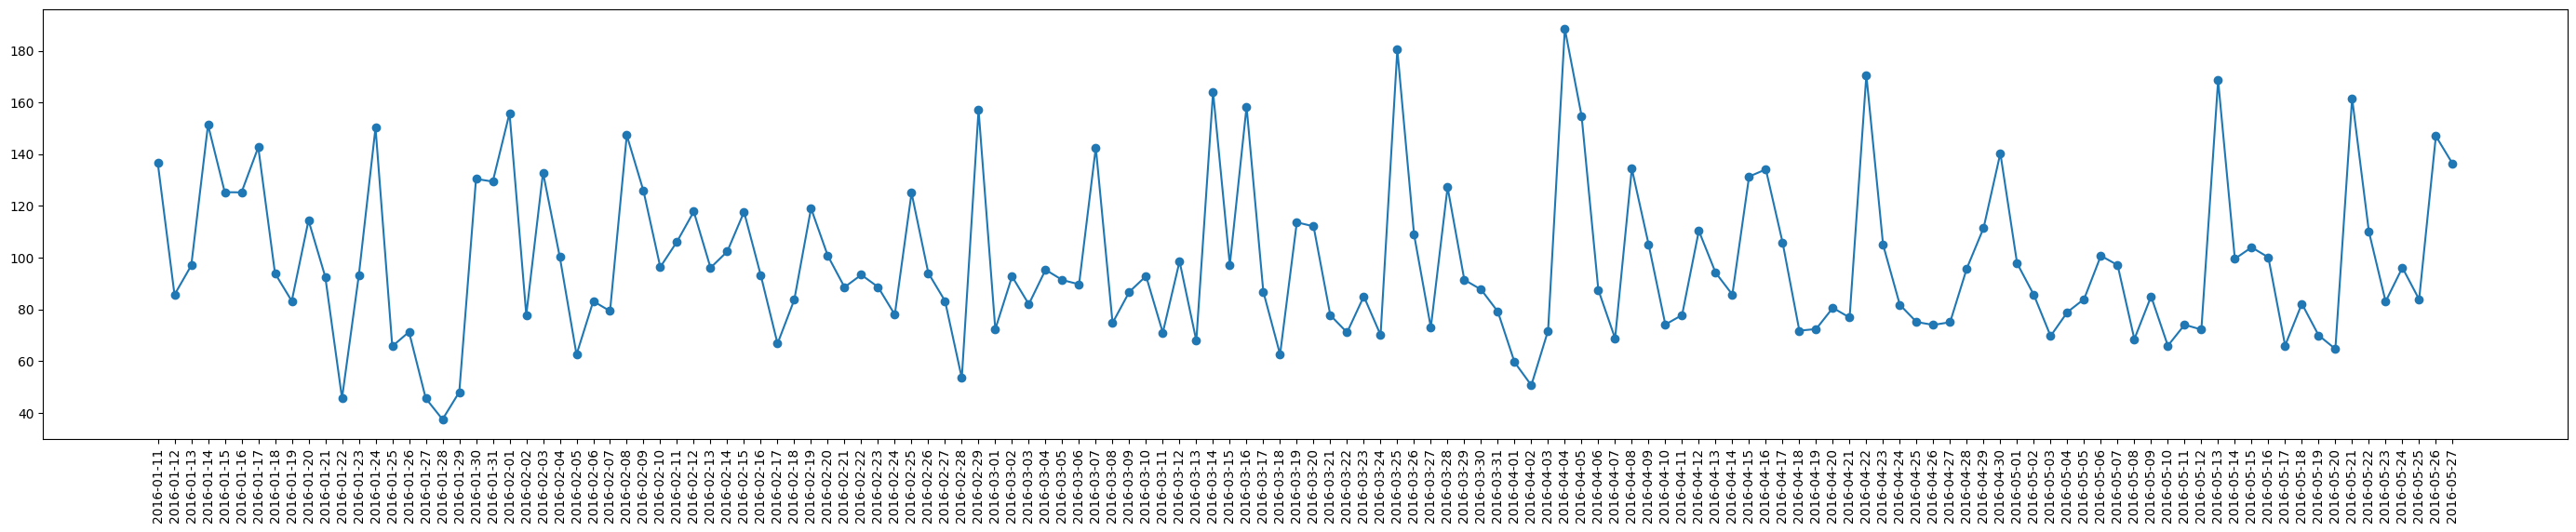

In [11]:
pivot2 = df.pivot_table(index = 'day',values = 'Appliances')
plt.figure(figsize=[35,6])
plt.plot(pivot2['Appliances'], marker = "o")
plt.xticks(pivot2.index,rotation = 90)
plt.show()

* There can some trend or seasonal flucuation.

**Time series decomposistion for energy consumption variables**

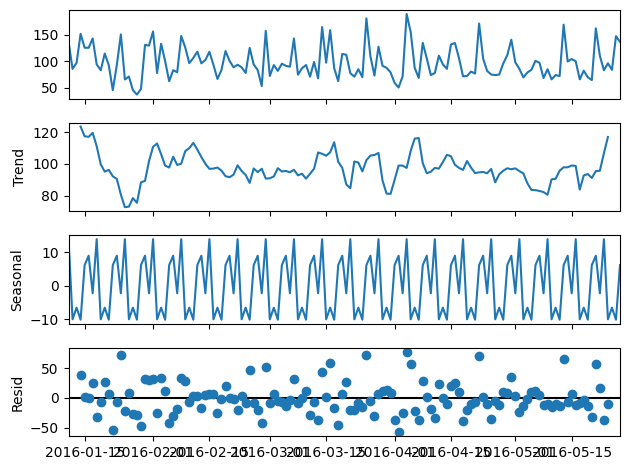

In [12]:
decomposition = seasonal_decompose(pivot2 , model='additive', period=7).plot()

* **There is a stable seasonality for week.**
* **No upword/downword trend in here.**

#### **Energy consumption in a week**

<Axes: xlabel='day1'>

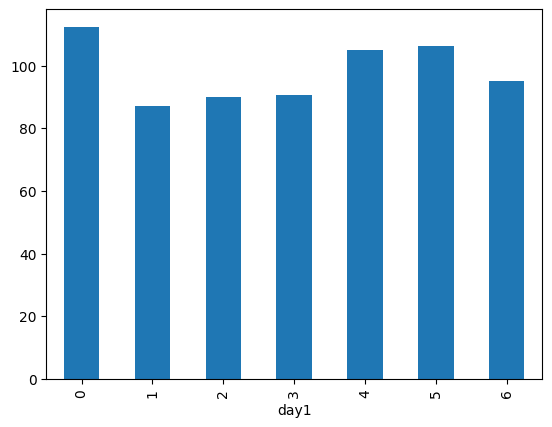

In [13]:
pivot2.index = pd.to_datetime(pivot2.index)
pivot2['day1'] = pivot2.index.dayofweek
pivot2.groupby('day1')['Appliances'].mean().plot(kind = 'bar')

* 0 is sunday when is the highest energy consumption
* 1 is Monday when is the lowest energy consumption

#### **Energy consumption month-wise plot**

In [14]:
pivot3 = df.pivot_table(index = 'month',values = 'Appliances')
pivot3

,Appliances
month,
1,97.026010
2,100.945881
3,96.953405
4,98.888889
5,94.199325


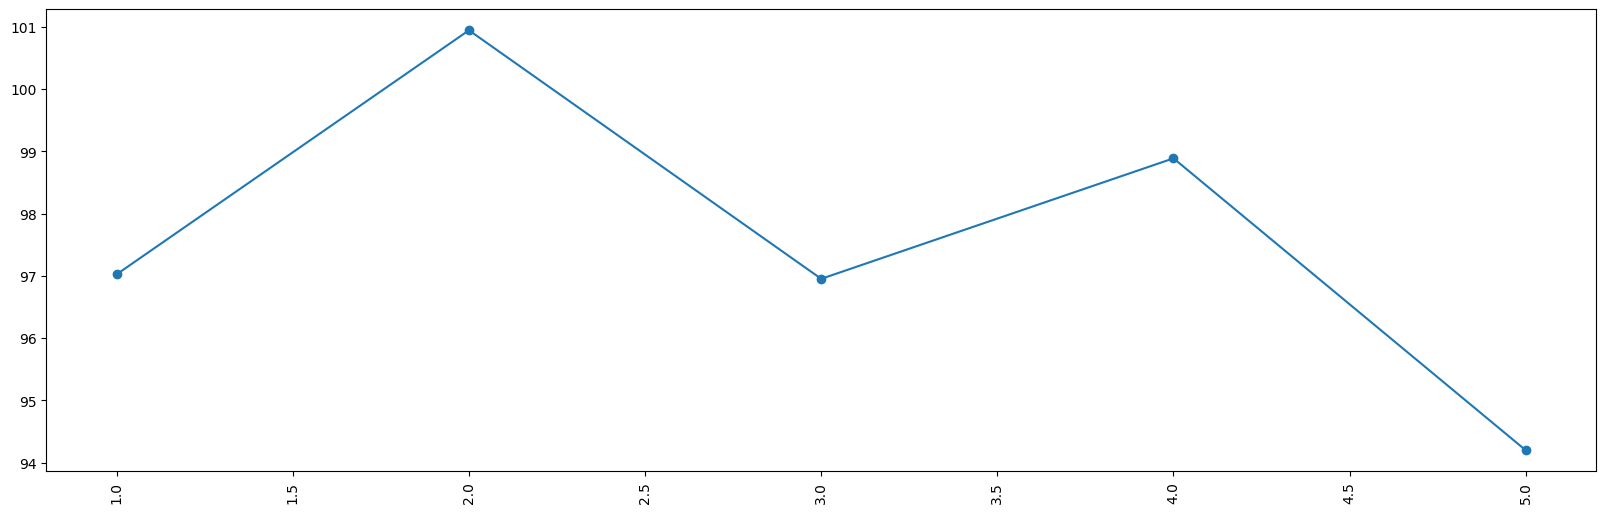

In [15]:

plt.figure(figsize=[20,6])
plt.plot(pivot3['Appliances'], marker = "o")
plt.xticks(rotation = 90)
plt.show()


* There are no meaningfull data.

# **Other Features**

Histogram of each variables

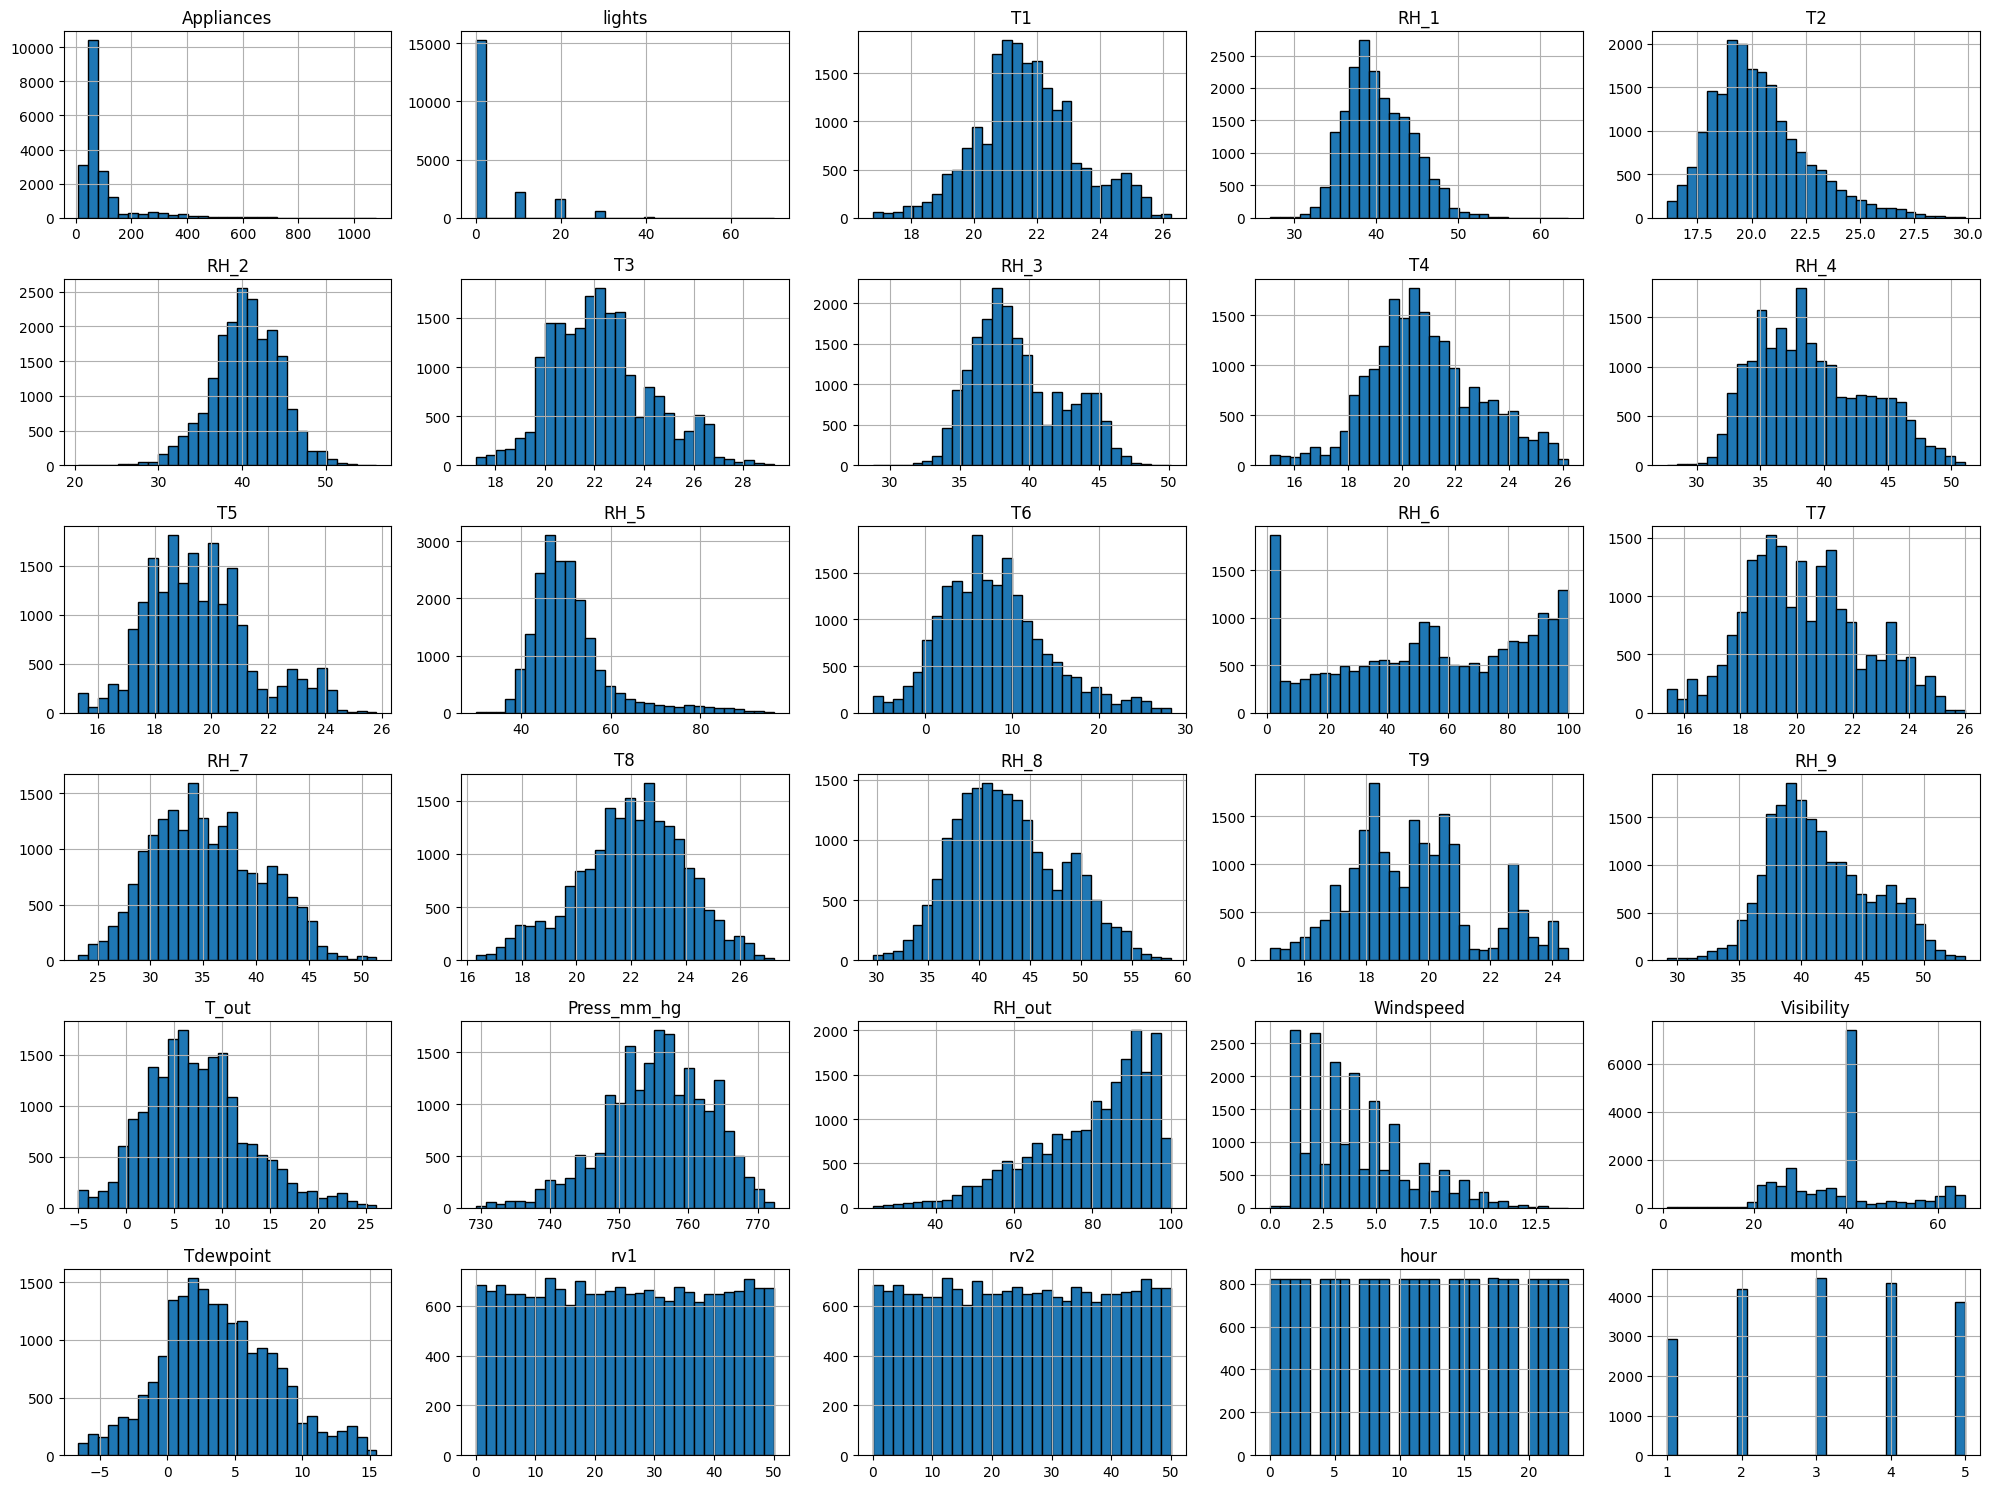

In [16]:
df.hist(
    bins=30,
    figsize=(20, 15),
    layout=(6, 5),
    edgecolor='black'
)

plt.tight_layout()
plt.show()

* According this plot, most of varibles are normally distributed, Also contains righj squness and right squness plots.
* final two variable which is high correlated with each other has same type of data distribution.

* we can see there are outlier in energy consumption


## **2. Missing value handdling**

### number of miussing values

In [17]:
sum(df.isna().sum())

0

* **No missing value in this dataset**

## **3. Outlier detection**

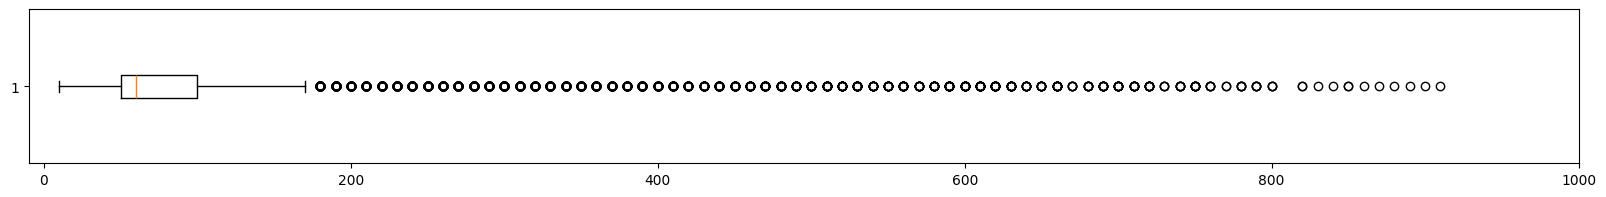

In [18]:
plt.figure(figsize=[20,2])
plt.boxplot(df['Appliances'], orientation='horizontal')
plt.xlim(-10,1000)
plt.show()

* **There are some outlies in target variable**

#### Outliers

In [19]:
q1 = df['Appliances'].quantile(0.25)
q3 = df['Appliances'].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df['Appliances']< lower) |(df['Appliances']> upper) ].index.tolist()

#### Number of outliers

In [20]:
len(outliers)

2138

##### Outlier dataset

In [21]:
outlier_data = df.loc[outliers,:]
outlier_data.index = pd.to_datetime(outlier_data.index)
outlier_data['day'] = outlier_data.index.date
outlier_data['hour'] = outlier_data.index.hour
outlier_data['month'] = outlier_data.index.month


#### day-wise outliers

In [22]:
outlier_data.groupby('day')['Appliances'].mean().sort_values(ascending = False).head(10)

,Appliances
day,
2016-04-18,463.333333
2016-01-18,457.647059
2016-03-31,435.000000
2016-01-21,431.333333
2016-01-30,428.518519
2016-03-21,418.000000
2016-03-01,416.000000
2016-05-14,415.714286
2016-04-19,410.000000


#### hour-wise outliers

In [23]:
outlier_data.groupby('hour')['Appliances'].mean().sort_values(ascending = False).head(10)

,Appliances
hour,
23,380.000000
1,375.000000
17,373.333333
18,369.169675
10,368.692810
11,363.672316
20,361.184211
16,354.687500
19,345.343511


* we can see that there are no outliers for some hours.

#### MOnth-wise outliers

In [24]:
outlier_data.groupby('month')['Appliances'].mean().sort_values(ascending = False).head(10)

,Appliances
month,
1,377.043011
4,358.444444
3,344.478261
5,335.866261
2,331.688805


* there no huge gap between month

### stationary of Appliances variable

In [25]:
result1 = adfuller(df['Appliances'])

In [26]:
stat, p_value, _, _  = kpss(df['Appliances'], regression='c')
p_value

/tmp/ipykernel_1810/881559844.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _  = kpss(df['Appliances'], regression='c')


np.float64(0.1)

In [ ]:
p_value

np.float64(0.1)

* Appliances vaiable has stationary property.

### **Outlier imputation**

In [27]:
q1 = df['Appliances'].quantile(0.25)
q3 = df['Appliances'].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df['Appliances']< lower) |(df['Appliances']> upper) ].index.tolist()

In [28]:
len(outliers)

2138

In [29]:
df1 = df.copy()
df1.loc[outliers,'Appliances'] = np.nan

## **1. Linear method**

In [33]:
df1['Appliances_clean'] = df1['Appliances'].interpolate(method='linear')

### 1. Box plot after outlier imputation method

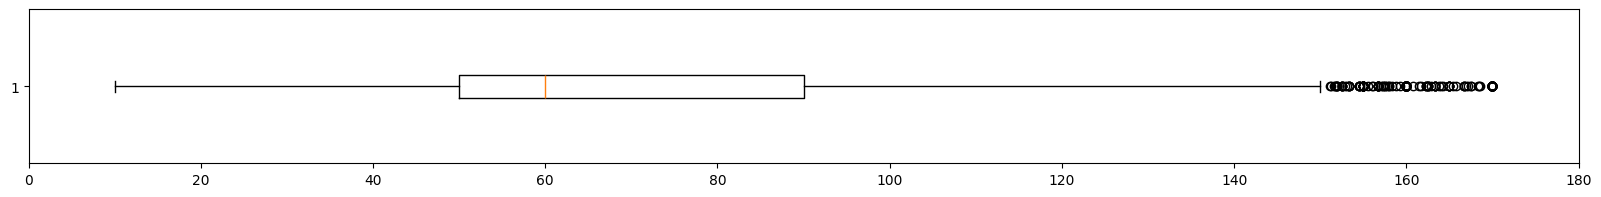

In [34]:
plt.figure(figsize=[20,2])
plt.boxplot(df1['Appliances_clean'], orientation='horizontal')
plt.xlim(0,180)
plt.show()

* **After appling Linear method to impute outliers, it can't completly impute them.**
* **WE have to move another method**

### **Remaining outliers**

In [35]:
q1 = df1['Appliances_clean'].quantile(0.25)
q3 = df1['Appliances_clean'].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
outlier2 = df1[(df1['Appliances_clean']< lower) |(df1['Appliances_clean']> upper) ].index.tolist()

df1.loc[outlier2,'Appliances_clean'] = np.nan



## **2. Rolling window method for outliers reduction**

In [37]:
df1['Appliances_imputed'] = df1['Appliances_clean'].fillna(
    df1['Appliances_clean'].rolling(window=15, min_periods=1, center=True).mean()
)

In [38]:
df1['Appliances_imputed'].isna().sum()

np.int64(0)

* No outler anymore.

* **About OUTLIERS,**
  * **According to details of outlier using outlier dataframe, we can decide that they are not error. they can be real value which is rare. So, here Removing method are not considered.**

  * **some model like LSTM are highly sensitivity to outliers, so imputing outliers should be needed.**

# **2. Feature Engineering**

## **2.1 Lag feature for time data**

### **Autocorrelation function**

<Figure size 2000x500 with 0 Axes>

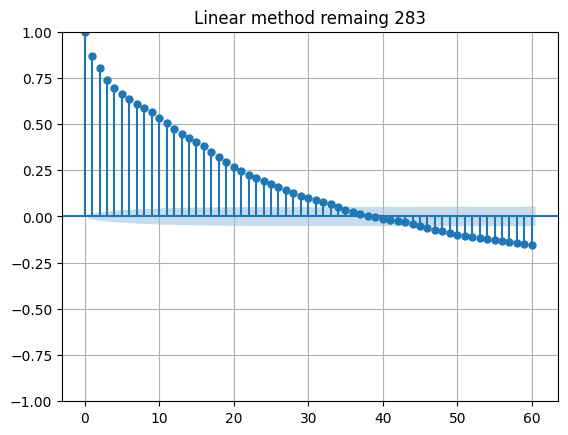

In [39]:
plt.figure(figsize = (20,5))
plot_acf(df1['Appliances_imputed'], lags=60, alpha=0.05, title="Linear method remaing 283")
plt.grid(True)
plt.show()


* According to ACF plot, we can decide that can add **34 lag feature** for Aplliances feature

#### **Adding 34 lags values**

In [40]:
lags = 34

lagged_df = pd.concat(
    [df1['Appliances_imputed'].shift(i) for i in range(1, lags + 1)],
    axis=1
)

lagged_df.columns = [f'lag_{i}' for i in range(1, lags + 1)]

df2 = pd.concat([df1, lagged_df], axis=1)

## **2.2 Adding rolling window technique**

In [41]:
df2.dropna(inplace = True)
df2['roll_mean_1hour'] = df2['Appliances_imputed'].shift(1).rolling(6).mean()
df2['roll_std_1hour'] = df2['Appliances_imputed'].shift(1).rolling(6).std()

df2['roll_mean_3hour'] = df2['Appliances_imputed'].shift(1).rolling(18).mean()
df2['roll_std_3hour'] = df2['Appliances_imputed'].shift(1).rolling(18).std()


* **Avoid from data leakge due to using lag values**
* **Rolling window method is applied for 1 hour and 3 hour data of Appliances feature**

In [42]:
df2.dropna(inplace = True)


In [43]:
sum(df2.isna().sum())
df2.drop(columns = ['Appliances','Appliances_clean'],axis = 1,inplace = True)

* **No any NA valey after adding lag values**

* **Finla dataset : df2**

## **2.3 Interaction Feature**

In [44]:
temp_cols = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T_out']
hum_cols  = ['RH_1','RH_2','RH_3','RH_4','RH_5','RH_6','RH_7','RH_8','RH_9','RH_out']

for t_col, h_col in itertools.product(temp_cols, hum_cols):
    interaction_name = f"{t_col}_x_{h_col}"
    df2[interaction_name] = df2[t_col] * df2[h_col]

/tmp/ipykernel_1810/3967809093.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2[interaction_name] = df2[t_col] * df2[h_col]
/tmp/ipykernel_1810/3967809093.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2[interaction_name] = df2[t_col] * df2[h_col]
/tmp/ipykernel_1810/3967809093.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

#### **Remove unneccessary variable**

In [53]:
df3 = df2.drop(columns = 'day').copy()

* **Download this Data file**

# **Random Forest ML model**

## **Data Splitting**

In [ ]:
# df3.to_csv("DATAFILE.csv")

In [54]:
split = int(len(df3) * 0.8)

train = df3[:split]
test = df3[split:]

X_train = train.drop('Appliances_imputed', axis=1)
y_train = train['Appliances_imputed']

X_test = test.drop('Appliances_imputed', axis=1)
y_test = test['Appliances_imputed']

In [55]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.to_frame())
y_test_scaled  = scaler_y.transform(y_test.to_frame())

y_train_scaled = y_train_scaled.ravel()
y_test_scaled  = y_test_scaled.ravel()

* **Following model is base model that use all variables**

In [57]:
rf_selector = RandomForestRegressor(
    n_estimators      = 200,
    max_depth         = 10,
    min_samples_split = 15,
    min_samples_leaf  = 8,
    max_features      = 0.3,
    random_state      = 42,
    n_jobs            = -1,
    max_samples       = 0.4
)
rf_selector.fit(X_train_scaled, y_train_scaled)

RandomForestRegressor(max_depth=10, max_features=0.3, max_samples=0.4,
                      min_samples_leaf=8, min_samples_split=15,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [58]:
y_pred_train = rf_selector.predict(X_train_scaled)
y_pred_test  = rf_selector.predict(X_test_scaled)

In [59]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


In [60]:
train_metrics = evaluate(y_train_scaled, y_pred_train, "TRAIN SET")
test_metrics  = evaluate(y_test_scaled,  y_pred_test,  "TEST SET")

## **Performance**

In [61]:
train_metrics

{'MAE': 0.3143749887651391,
 'MSE': 0.20241038263300973,
 'RMSE': np.float64(0.4499004141285155),
 'R2': 0.7975896173669903,
 'MAPE': 64.75388248418585}

In [62]:
test_metrics

{'MAE': 0.3344988650626858,
 'MSE': 0.21904987431601783,
 'RMSE': np.float64(0.4680276426836537),
 'R2': 0.7318018842268961,
 'MAPE': 74.13221891485686}

* **we can see that this model is not overfitted model.**

## **1. Feature selection method : Permutation Importance**

* Long time

In [64]:
perm = permutation_importance(
    rf_selector,
    X_test_scaled,
    y_test_scaled,
    n_repeats    = 30,        # shuffle each feature 30× for stable estimate
    scoring      = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs       = -1
)

In [ ]:
feature_names = [f"feature_{i}" for i in range(X_train_scaled.shape[1])]

In [ ]:
perm_df = pd.DataFrame({
    'Feature' : feature_names,
    'Mean'    : perm.importances_mean,   # avg RMSE increase when shuffled
    'Std'     : perm.importances_std,    # stability across 30 repeats
}).sort_values('Mean', ascending=False).reset_index(drop=True)

In [ ]:
selected_feats = perm_df[perm_df['Mean'] > 0]['Feature'].tolist()

print(f"Selected : {len(selected_feats)} / {len(feature_names)} features")
print(f"Features : {selected_feats}")


In [ ]:
# Get final arrays
feat_idx     = [list(feature_names).index(f) for f in selected_feats]
X_train_sel  = X_train_scaled[:, feat_idx]
X_test_sel   = X_test_scaled[:, feat_idx]

## **Retrain the model using new seleced features**

In [ ]:
rf_selector_new = RandomForestRegressor(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_split = 15,
    min_samples_leaf  = 8,
    max_features      = 0.3,
    random_state      = 42,
    n_jobs            = -1,
    max_samples       = 0.4
)
rf_selector_new.fit(X_train_sel, y_train_scaled)

In [ ]:
y_pred_train = rf_selector_new.predict(X_train_sel)
y_pred_test  = rf_selector_new.predict(X_test_sel)

In [ ]:
train_metrics = evaluate(y_train_scaled, y_pred_train, "TRAIN SET")
test_metrics  = evaluate(y_test_scaled,  y_pred_test,  "TEST SET")

## **Performance**

In [ ]:
train_metrics

In [ ]:
test_metrics

# **2. Feature selection method : Correlation analysis**

In [65]:
df4 = df3.copy()
correlation = df4.corr()["Appliances_imputed"].abs().sort_values(ascending=False)
selected_features = correlation[correlation > 0.1].index

## **Removing Feature that have Multicolinearity features**

In [66]:
top_feature = selected_features.drop('Appliances_imputed')
corr_matrix = df4[top_feature].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_final = df4[top_feature].drop(columns=to_drop)

In [67]:
final_feature = X_final.columns.tolist()
final_feature.append("Appliances_imputed")

## Retrain the RF model

In [68]:
df5 = df4[final_feature]

split = int(len(df5) * 0.8)

train = df5[:split]
test = df5[split:]

X_train = train.drop('Appliances_imputed', axis=1)
y_train = train['Appliances_imputed']

X_test = test.drop('Appliances_imputed', axis=1)
y_test = test['Appliances_imputed']

scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.to_frame())
y_test_scaled  = scaler_y.transform(y_test.to_frame())

y_train_scaled = y_train_scaled.ravel()
y_test_scaled  = y_test_scaled.ravel()

In [69]:
rf_selector_using_cor = RandomForestRegressor(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_split = 15,
    min_samples_leaf  = 8,
    max_features      = 0.3,
    random_state      = 42,
    n_jobs            = -1,
    max_samples       = 0.4
)
rf_selector_using_cor.fit(X_train_scaled, y_train_scaled)

RandomForestRegressor(max_depth=10, max_features=0.3, max_samples=0.4,
                      min_samples_leaf=8, min_samples_split=15,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [70]:
y_pred_train = rf_selector_using_cor.predict(X_train_scaled)
y_pred_test  = rf_selector_using_cor.predict(X_test_scaled)
train_metrics = evaluate(y_train_scaled, y_pred_train, "TRAIN SET")
test_metrics  = evaluate(y_test_scaled,  y_pred_test,  "TEST SET")

In [71]:
train_metrics

{'MAE': 0.3188513753415544,
 'MSE': 0.20834600629358335,
 'RMSE': np.float64(0.45644934690892414),
 'R2': 0.7916539937064166,
 'MAPE': 65.65526129693725}

In [72]:
test_metrics

{'MAE': 0.3315294759564303,
 'MSE': 0.21479083951594052,
 'RMSE': np.float64(0.46345532634326314),
 'R2': 0.737016519076423,
 'MAPE': 75.94754395610018}

# **Plot**

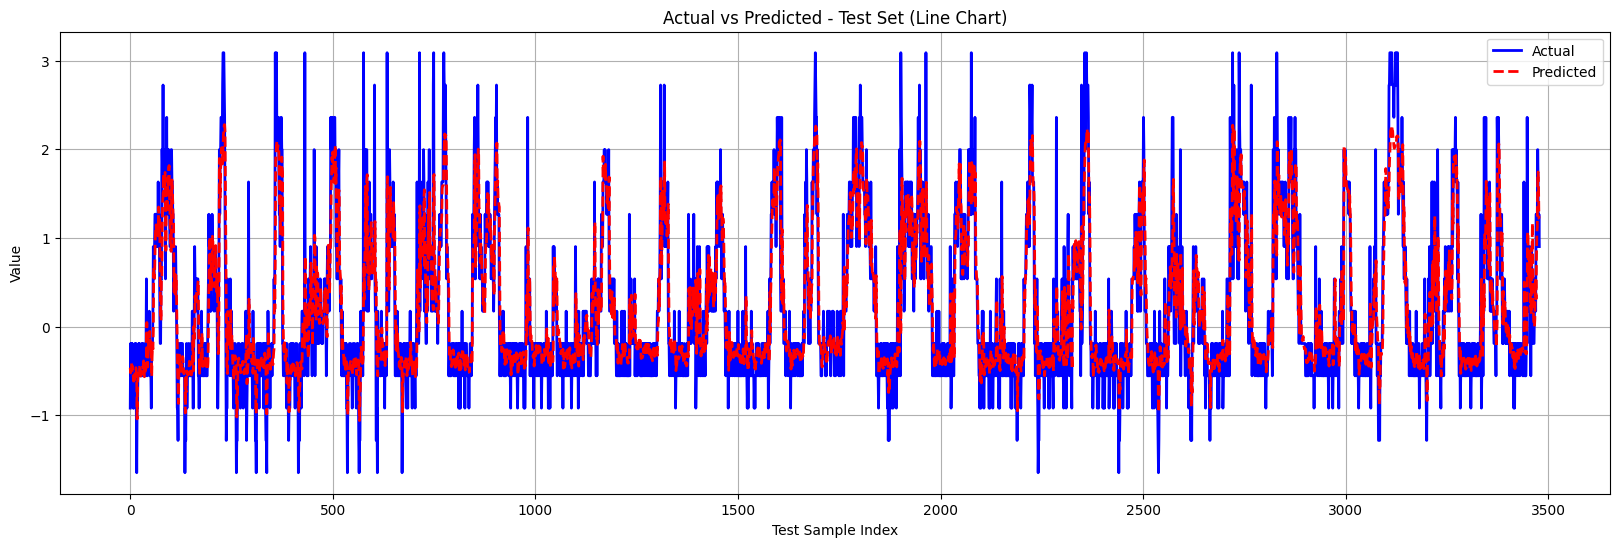

In [74]:
plt.figure(figsize=(20, 6))

plt.plot(y_test_scaled, label='Actual', color='blue', linewidth=2)
plt.plot(y_pred_test, label='Predicted', color='red', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted - Test Set (Line Chart)')
plt.xlabel('Test Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# **Hyperparamter tuning of RF model**

* Very long time. Didn't run

In [ ]:
param_dist = {
    'n_estimators'      : [150,200,250,300,275],
    'max_depth'         : [10, 15, 20, 25],
    'min_samples_split' : [5, 8, 10, 15,12],
    'min_samples_leaf'  : [ 4, 6, 8,5],
    'max_features'      : [0.3, 0.4, 0.5, 0.6],
    'max_samples'       : [0.5, 0.6, 0.7, 0.8],
}

search = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter      = 60,
    scoring     = 'neg_root_mean_squared_error',
    cv          = 5,
    random_state= 42,
    n_jobs      = -1,
    verbose     = 2
)

search.fit(X_train_scaled, y_train_scaled)

In [ ]:
# Best params
print("Best Params :", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.4f}")

# Evaluate
best_rf = search.best_estimator_
print(f"\nTrain RMSE : {np.sqrt(mean_squared_error(y_train_scaled, best_rf.predict(X_train_scaled))):.4f}")
print(f"Test  RMSE : {np.sqrt(mean_squared_error(y_test_scaled,  best_rf.predict(X_test_scaled))):.4f}")

# **DEEP LEARNING MODEL: LSTM**

## **1. Feature selection for LSTM model**

### **Method 1 : Correlation Analysis**

* df3 is only name of data set. **it is a data frame which was created in Feature engineering part**

In [75]:
correlation = df3.corr()["Appliances_imputed"].abs().sort_values(ascending=False)
selected_features = correlation[correlation > 0.1].index
selected_features
top_feature = selected_features.drop('Appliances_imputed')

corr_matrix = df3[top_feature].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

X_final = df3[top_feature].drop(columns=to_drop)
final_feature = X_final.columns.tolist()
final_feature.append("Appliances_imputed")
lstm_data = df3[final_feature]
len(lstm_data.columns)

15

In [ ]:
lstm_data = pd.read_csv('gpu.csv')
lstm_data.index = lstm_data['Unnamed: 0'].tolist()
lstm_data.drop(columns=['Unnamed: 0'], inplace=True)

target_column = 'Appliances_imputed'

X = lstm_data.drop(columns=[target_column]).values
y = lstm_data[target_column].values.reshape(-1, 1)

def time_series_split(X, y, train_ratio=0.8):
    split_index = int(len(X) * train_ratio)

    X_train = X[:split_index]
    X_test  = X[split_index:]

    y_train = y[:split_index].reshape(-1, 1)
    y_test  = y[split_index:].reshape(-1, 1)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = time_series_split(X,y)

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit and transform on training data
X_train = feature_scaler.fit_transform(X_train)
y_train = target_scaler.fit_transform(y_train)

# Only transform on test data
X_test = feature_scaler.transform(X_test)
y_test = target_scaler.transform(y_test)

# def create_sequences(X, y, seq_len):
#     X_seq, y_seq = [], []
#     for i in range(len(X) - seq_len):
#         X_seq.append(X[i : i + seq_len])
#         y_seq.append(y[i + seq_len])
#     return np.array(X_seq), np.array(y_seq)

# SEQUENCE_LENGTH = 60  # tune this based on your data

# X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQUENCE_LENGTH)
# X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  SEQUENCE_LENGTH)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Reshape

# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

with tf.device(device):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(16, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(8, return_sequences=False, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=5,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model.predict(X_test)

# --- Evaluation ---
test_loss, test_mae, test_mse = model.evaluate(X_test, y_test)

# y_pred = target_scaler.inverse_transform(y_pred_scaled)
# y_true = target_scaler.inverse_transform(X_test)

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2   = r2_score(y_true, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test)
test_mae

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Reshape

# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

with tf.device(device):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        LSTM(8, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model.predict(X_test)

# --- Evaluation ---


# y_pred = target_scaler.inverse_transform(y_pred_scaled)
# y_true = target_scaler.inverse_transform(X_test)

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2   = r2_score(y_true, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")

test_loss, test_mae = model.evaluate(X_test, y_test)
test_loss, test_mae

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Reshape

# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

with tf.device(device):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True, activation='relu'),
        Dropout(0.3),
        LSTM(16, return_sequences=True, activation='relu'),
        Dropout(0.3),
        LSTM(8, return_sequences=False, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='relu')
    ])

    model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model.predict(X_test)

# --- Evaluation ---


# y_pred = target_scaler.inverse_transform(y_pred_scaled)
# y_true = target_scaler.inverse_transform(X_test)

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2   = r2_score(y_true, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")
test_loss, test_mae = model.evaluate(X_test, y_test)
test_loss, test_mae



In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Reshape

# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

with tf.device(device):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        LSTM(8, return_sequences=True),
        Dropout(0.3),
        LSTM(4, return_sequences=False),
        Dropout(0.3),
        Dense(1, activation='relu')
    ])

    model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model.predict(X_test)

test_loss, test_mae = model.evaluate(X_test, y_test)
test_loss, test_mae

# --- Evaluation ---


# y_pred = target_scaler.inverse_transform(y_pred_scaled)
# y_true = target_scaler.inverse_transform(X_test)

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2   = r2_score(y_true, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Reshape

# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

with tf.device(device):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model.predict(X_test)

test_loss, test_mae = model.evaluate(X_test, y_test)
test_loss, test_mae

# --- Evaluation ---


# y_pred = target_scaler.inverse_transform(y_pred_scaled)
# y_true = target_scaler.inverse_transform(X_test)

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2   = r2_score(y_true, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")